### Closing price prediction of a stock using data from the last 60 days via Linear Regression

In [32]:
# Import necessary libraries
import pandas as pd
import numpy as np
import math
import time
import matplotlib.pyplot as plt 
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.preprocessing import MinMaxScaler

In [33]:
start_time = time.time()

In [34]:
# Load data
df = pd.read_csv('../Download data/data.csv', index_col=0, parse_dates=True)

# Display data
df

,close
date,
2015-01-02,205.43
2015-01-05,201.72
2015-01-06,199.82
2015-01-07,202.31
2015-01-08,205.90
...,...
2024-12-24,601.30
2024-12-26,601.34
2024-12-27,595.01


In [35]:
# Extract 'Close' prices as Dataframe
data = df[['close']].copy()

In [36]:
# Scale data between 0 and 1
scaler = MinMaxScaler((0,1))
scaled_data = scaler.fit_transform(data)

In [37]:
# Create sliding window sequences
window = 60
x, y = [], []
for i in range(window, len(scaled_data)):
    x.append(scaled_data[i-window:i,0])
    y.append(scaled_data[i,0])
x = np.array(x)
y = np.array(y)

In [38]:
# Split training and test sets
train_size = int(len(x) * 0.8)
x_train, x_test = x[:train_size], x[train_size:]
y_train, y_test = y[:train_size], y[train_size:]

In [39]:
# Train the model
lr = LinearRegression().fit(x_train, y_train)

In [40]:
# Predict and inverse scale
y_pred_scaled = lr.predict(x_test).reshape(-1,1)
y_pred = scaler.inverse_transform(y_pred_scaled)
y_test_inv = scaler.inverse_transform(y_test.reshape(-1,1))

In [41]:
# Metrics
rmse = np.sqrt(mean_squared_error(y_test_inv, y_pred))
mae = mean_absolute_error(y_test_inv, y_pred)
r2 = r2_score(y_test_inv, y_pred)

print(f"RMSE: {rmse:.4f}")
print(f"MAE:  {mae:.4f}")
print(f"R²:   {r2:.4f}")

RMSE: 4.0638
MAE:  3.1349
R²:   0.9960


In [42]:
# Dataframe for plotting 
train = df[['close']][:train_size+window]
valid = df[['close']][train_size+window:].copy()
valid['Predictions'] = y_pred

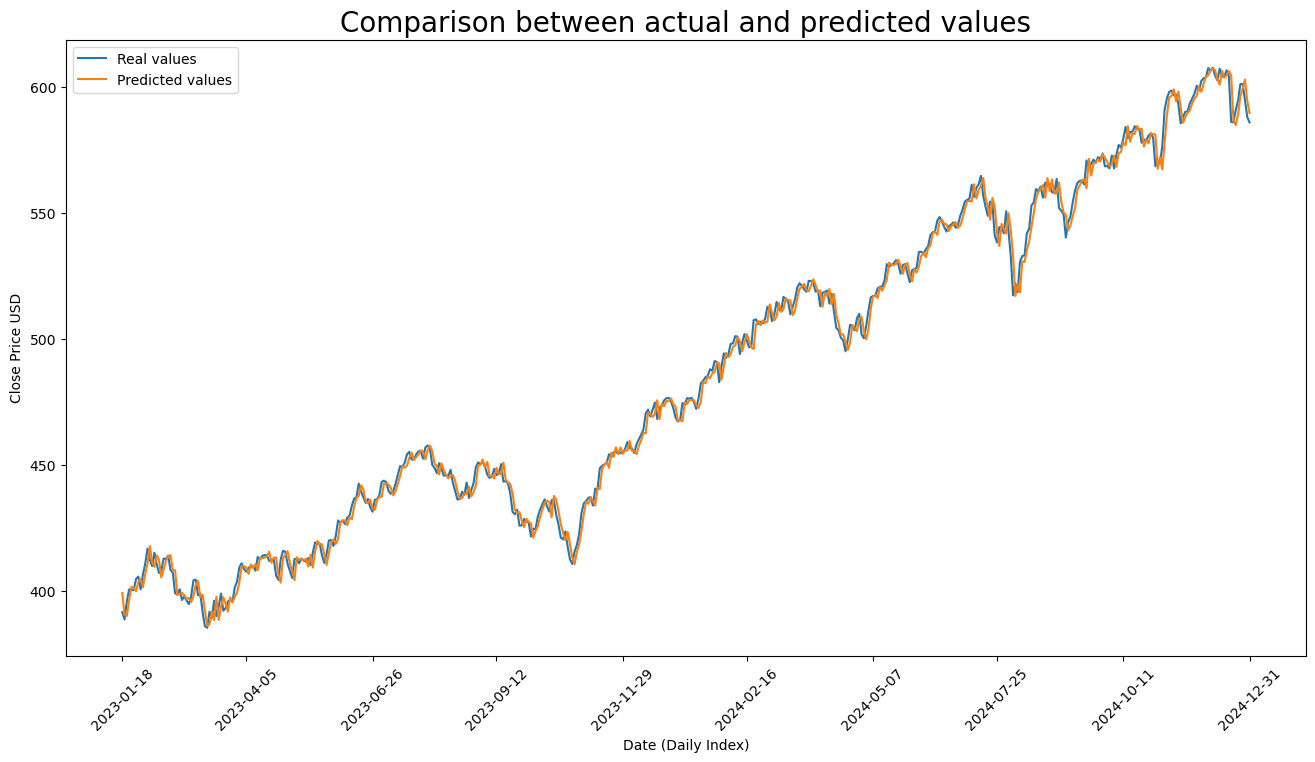

,close,Predictions
date,,
2023-01-18,391.49,399.154533
2023-01-19,388.64,390.490667
2023-01-20,395.88,390.064504
2023-01-23,400.63,396.624381
2023-01-24,400.20,401.616938
...,...,...
2024-12-24,601.30,596.516226
2024-12-26,601.34,599.572373
2024-12-27,595.01,603.108368


In [43]:
# Plot & display actual vs predicted values
plt.figure(figsize=(16, 8))
plt.plot(y_test_inv, label='Real values')  
plt.plot(y_pred, label='Predicted values')            
plt.title('Comparison between actual and predicted values', fontsize=20)
plt.xlabel('Date (Daily Index)')
plt.xticks(ticks=np.linspace(0, len(valid.index)-1, 10, dtype=int),  
           labels=[valid.index[i].strftime('%Y-%m-%d') for i in np.linspace(0, len(valid.index)-1, 10, dtype=int)],
           rotation=45)
plt.ylabel('Close Price USD')
plt.legend()
plt.show()

valid

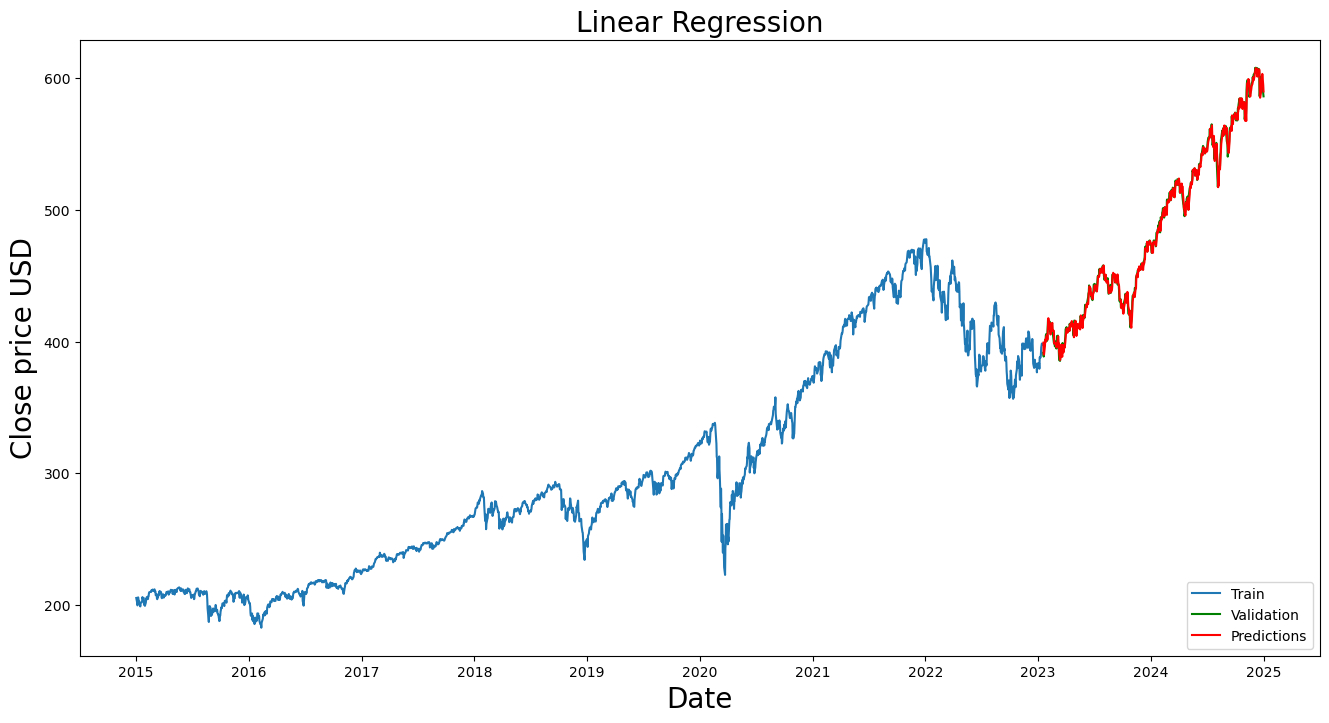

In [44]:
# Plot training, validation and predictions
plt.figure(figsize=(16,8))
plt.title('Linear Regression', fontsize=20)
plt.xlabel('Date', fontsize=20)
plt.ylabel('Close price USD', fontsize=20)
plt.plot(train['close'], label='Train')
plt.plot(valid['close'], color='green', label='Validation')
plt.plot(valid['Predictions'], color='red', label='Predictions')
plt.legend(loc='lower right')
plt.show()

In [45]:
end_time = time.time()
elapsed_time = end_time - start_time

print(f"Execution time: {elapsed_time:.2f} seconds")

Execution time: 0.56 seconds
